In [49]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt

train_data_pl = pl.read_csv(r"../data/train.csv",encoding="shift_jis")

In [81]:
import importlib
import ml_pipeline
import mlflow

In [82]:
#リロード
importlib.reload(ml_pipeline)

/usr/local/lib/python3.11/site-packages/mlflow/pyfunc/utils/data_validation.py:186: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


<module 'ml_pipeline' from '/work/ml_pipeline.py'>

In [83]:
mlflow.set_tracking_uri("http://mlflow:5000")
mlflow.set_experiment("exp2")

<Experiment: artifact_location='/mlruns/1', creation_time=1775686978108, experiment_id='1', last_update_time=1775686978108, lifecycle_stage='active', name='exp2', tags={}, workspace='default'>

In [87]:
from ml_pipeline import MoisturePipeline, FullPipelineModel

pipe = MoisturePipeline(
    use_pca=False,
    use_diff=True,
    params={
        "verbosity": -1,
        "n_estimators": 100,
        "learning_rate": 0.05,
        "num_leaves": 64,
        "min_data_in_leaf": 5,
        "n_jobs": -1,
    }
)
rmse = pipe.fit(train_data_pl)

with mlflow.start_run():
    mlflow.log_params(pipe.params)
    #mlflow.log_param("pca_components", pipe.fe.pca.n_components)

    mlflow.log_metric("rmse", rmse)

    mlflow.pyfunc.log_model(
        name="model",
        python_model=FullPipelineModel(pipe)
    )

/usr/local/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
2026/04/12 22:10:39 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.


🏃 View run placid-shrimp-350 at: http://mlflow:5000/#/experiments/1/runs/089c88f5222246e1a222fe44eb86dfbe
🧪 View experiment at: http://mlflow:5000/#/experiments/1


### sharpray値を使い　2次微分は1,特定の特徴量だけが落としている　or 2.全体的に効いていない　をみる

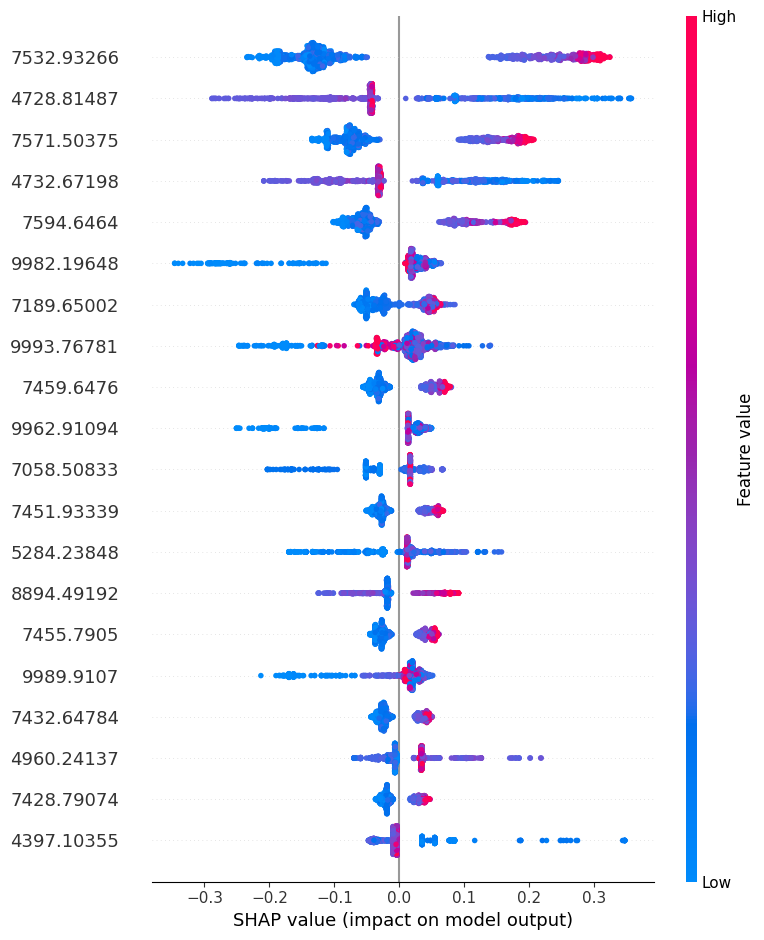


=== SHAP importance ===
7532.93266    0.173428
4728.81487    0.116763
7571.50375    0.104498
4732.67198    0.085988
7594.6464     0.079646
9982.19648    0.048640
7189.65002    0.042985
9993.76781    0.042398
7459.6476     0.041908
9962.91094    0.038227
7058.50833    0.037494
7451.93339    0.036733
5284.23848    0.034641
8894.49192    0.033702
7455.7905     0.033198
9989.9107     0.033103
7432.64784    0.029818
4960.24137    0.027115
7428.79074    0.024909
4397.10355    0.024871
dtype: float64


7532.93266    0.173428
4728.81487    0.116763
7571.50375    0.104498
4732.67198    0.085988
7594.6464     0.079646
                ...   
5681.52064    0.000000
7332.36303    0.000000
9689.05625    0.000000
5669.94932    0.000000
6769.2252     0.000000
Length: 1555, dtype: float64

In [88]:
from ml_pipeline import FeatureEngineer  # 定義している場所からimport

# SHAP可視化

pipe.fe.show_shap(train_data_pl, pipe.model, pipe.feature_cols)

#pipe.fe.show_shap(train_data_pl, pipe.model, pipe.feature_cols)


## モデルを引き落としてきて実験する

In [111]:
test_data_pl = pl.read_csv(r"../data/test.csv",encoding="shift_jis")

In [89]:
import mlflow

experiment_name = "exp2"  # もしくはあなたの実験名

experiment = mlflow.get_experiment_by_name(experiment_name)

runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=["start_time DESC"],
    max_results=1
)

latest_run_id = runs.iloc[0]["run_id"]
print(latest_run_id)

089c88f5222246e1a222fe44eb86dfbe


In [106]:
model_uri = mlflow.pyfunc.load_model(f"runs:/{latest_run_id}/model")

In [107]:
model_uri

mlflow.pyfunc.loaded_model:
  artifact_path: /mlruns/1/models/m-613eac1a09a249748c971c826cdeb8b2/artifacts
  flavor: mlflow.pyfunc.model
  run_id: 089c88f5222246e1a222fe44eb86dfbe

In [112]:
model = mlflow.pyfunc.load_model(
    "runs:/089c88f5222246e1a222fe44eb86dfbe/model"
)

y_pred = model.predict(test_data_pl)

/usr/local/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [115]:
submission = pd.DataFrame({
    "id": test_data_pl["sample number"],
    "含水率": y_pred
})

submission.head()
submission.to_csv(r"../data/submission.csv",index=False,header = False)

In [117]:
!ls ../data

pred.csv  pred.txt  sample_submit.csv  submission.csv  test.csv  train.csv
